In [80]:
!pip install --upgrade pip -q

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn plotly xgboost lightgbm shap streamlit -q

In [81]:
print("✅ All libraries ready!")

✅ All libraries ready!


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Names & Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())


Dataset Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract 

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


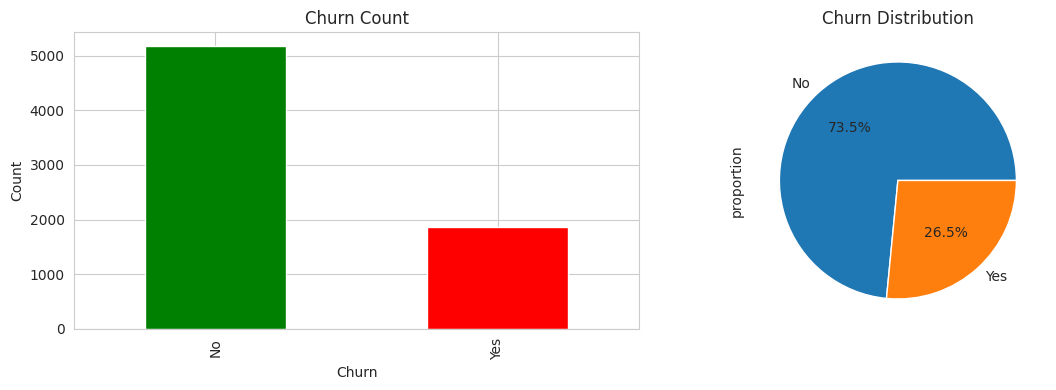

In [83]:
# Churn distribution
import os
os.makedirs("outputs", exist_ok=True)
print("Churn Distribution:")
print(df['Churn'].value_counts())
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

# Percentage pie chart
df['Churn'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Churn Distribution')

plt.tight_layout()
plt.savefig('outputs/01_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [84]:
# Numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric Columns:")
print(numeric_cols)

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical Columns:")
print(categorical_cols)

# Remove customerID (not useful)
df_analysis = df.drop('customerID', axis=1)

print("\nData Info:")
print(df_analysis.info())


Numeric Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 


In [85]:
# Check for missing values
print("Missing Values:")
print(df_analysis.isnull().sum())

# TotalCharges might be object type (contains spaces), convert
if df_analysis['TotalCharges'].dtype == 'object':
    df_analysis['TotalCharges'] = pd.to_numeric(
        df_analysis['TotalCharges'],
        errors='coerce'
    )

# Fill missing TotalCharges with 0 (new customers)
df_analysis['TotalCharges'].fillna(0, inplace=True)

print("\nAfter handling:")
print(df_analysis.isnull().sum())


Missing Values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

After handling:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


RFM + RSS Features Created:
           Recency    Frequency     Monetary    RSS_Score
count  7043.000000  7043.000000  7043.000000  7043.000000
mean      2.255999     1.222916    64.761692     1.211984
std       3.925778     0.778877    30.090047     1.386351
min       0.000000     0.000000    18.250000     0.000000
25%       0.000000     1.000000    35.500000     0.000000
50%       0.000000     1.000000    70.350000     1.000000
75%       3.000000     2.000000    89.850000     2.000000
max      12.000000     2.000000   118.750000     4.000000


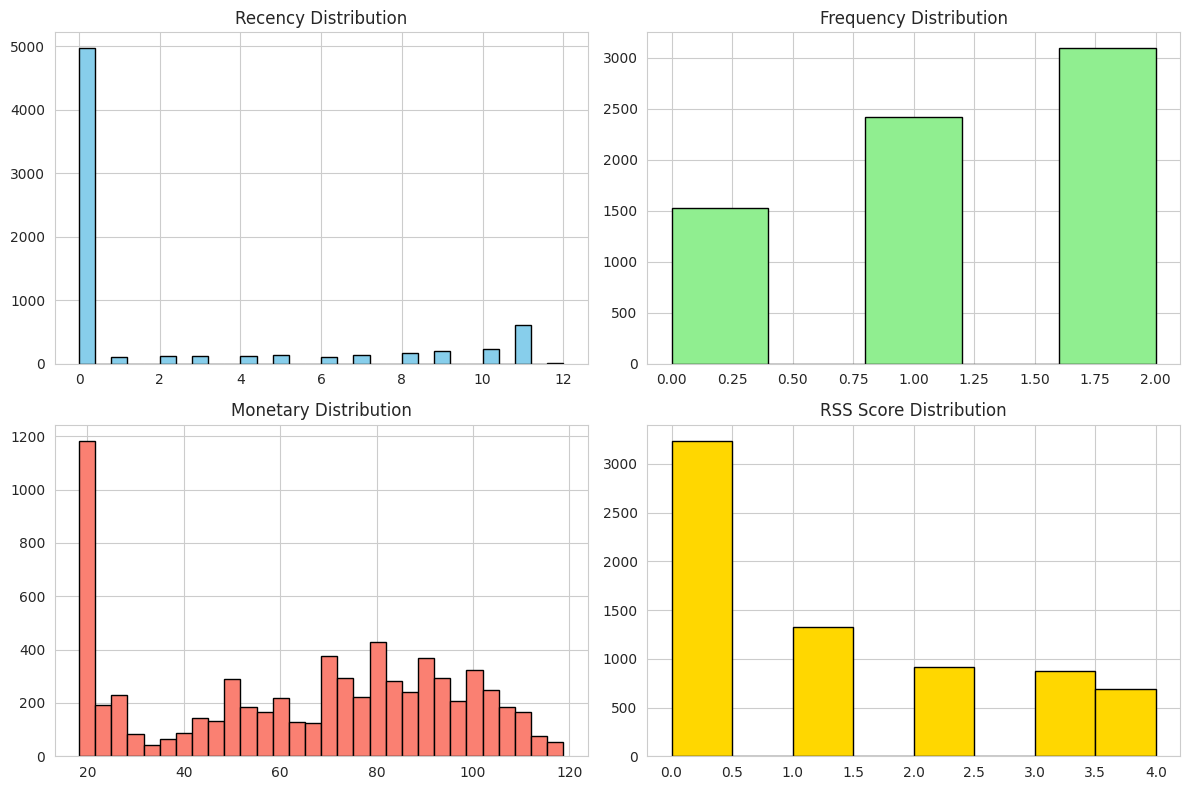

In [86]:
# ============ RFM FEATURES ============

# 1. RECENCY: How long since last activity (use tenure as proxy)
#    Low tenure = recent customer, High tenure = old but active
df_analysis['Recency'] = 12 - df_analysis['tenure']  # Approximate months
df_analysis['Recency'] = df_analysis['Recency'].clip(lower=0)  # No negative

# 2. FREQUENCY: Activity frequency (telecom = always monthly)
#    Use InternetService as proxy (higher tier = more engaged)
df_analysis['Frequency'] = df_analysis['InternetService'].map({
    'No': 0,
    'DSL': 1,
    'Fiber optic': 2
})

# 3. MONETARY: Customer value
df_analysis['Monetary'] = df_analysis['MonthlyCharges']

# ============ RSS FEATURES (Retention Support Score) ============

# Engagement indicators
df_analysis['RSS_Score'] = 0

# Add points for services (higher = more engaged, less churn)
df_analysis['RSS_Score'] += df_analysis['TechSupport'].map(
    {'Yes': 2, 'No': 0, 'No internet service': 0}
).fillna(0)

df_analysis['RSS_Score'] += df_analysis['OnlineBackup'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 0}
).fillna(0)

df_analysis['RSS_Score'] += df_analysis['OnlineSecurity'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 0}
).fillna(0)

print("RFM + RSS Features Created:")
print(df_analysis[['Recency', 'Frequency', 'Monetary', 'RSS_Score']].describe())

# Visualize RFM
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df_analysis['Recency'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Recency Distribution')

axes[0, 1].hist(df_analysis['Frequency'], bins=5, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Frequency Distribution')

axes[1, 0].hist(df_analysis['Monetary'], bins=30, color='salmon', edgecolor='black')
axes[1, 0].set_title('Monetary Distribution')

axes[1, 1].hist(df_analysis['RSS_Score'], bins=8, color='gold', edgecolor='black')
axes[1, 1].set_title('RSS Score Distribution')

plt.tight_layout()
plt.savefig('outputs/02_rfm_rss_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


In [87]:
# =========================
# ENCODING CATEGORICAL DATA
# =========================

# Binary encoding (ONLY true text-based binary columns)
binary_cols = ['gender', 'Partner', 'Dependents',
               'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    if col in df_analysis.columns:
        df_analysis[col] = df_analysis[col].map({
            'Yes': 1,
            'No': 0,
            'Male': 1,
            'Female': 0
        })

# Handle Churn separately and safely
if 'Churn' in df_analysis.columns and df_analysis['Churn'].dtype == 'object':
    df_analysis['Churn'] = df_analysis['Churn'].map({'Yes': 1, 'No': 0})

# Keep SeniorCitizen numeric
if 'SeniorCitizen' in df_analysis.columns:
    df_analysis['SeniorCitizen'] = pd.to_numeric(
        df_analysis['SeniorCitizen'],
        errors='coerce'
    ).fillna(0).astype(int)

# One-hot encode remaining categorical columns
remaining_categorical_cols = df_analysis.select_dtypes(include='object').columns.tolist()
remaining_categorical_cols = [col for col in remaining_categorical_cols if col != 'Churn']

df_analysis = pd.get_dummies(
    df_analysis,
    columns=remaining_categorical_cols,
    drop_first=True
)

print(f"Shape after encoding: {df_analysis.shape}")
print(f"Total features: {df_analysis.shape[1]}")

print("\nRemaining object columns:")
print(df_analysis.select_dtypes(include='object').columns.tolist())

Shape after encoding: (7043, 35)
Total features: 35

Remaining object columns:
[]


In [88]:
from sklearn.preprocessing import StandardScaler

# Select RFM + RSS for clustering
clustering_features = ['Recency', 'Frequency', 'Monetary', 'RSS_Score']
X_cluster = df_analysis[clustering_features].copy()

# Check for NaN
print(f"Missing in clustering features: {X_cluster.isnull().sum()}")
X_cluster = X_cluster.fillna(0)

# Scale
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Scaled Features (mean ≈ 0, std ≈ 1):")
print(pd.DataFrame(X_cluster_scaled, columns=clustering_features).describe())

Missing in clustering features: Recency      0
Frequency    0
Monetary     0
RSS_Score    0
dtype: int64
Scaled Features (mean ≈ 0, std ≈ 1):
            Recency     Frequency      Monetary     RSS_Score
count  7.043000e+03  7.043000e+03  7.043000e+03  7.043000e+03
mean   5.851410e-17 -5.145205e-17 -6.406285e-17 -4.388557e-17
std    1.000071e+00  1.000071e+00  1.000071e+00  1.000071e+00
min   -5.747036e-01 -1.570214e+00 -1.545860e+00 -8.742876e-01
25%   -5.747036e-01 -2.862227e-01 -9.725399e-01 -8.742876e-01
50%   -5.747036e-01 -2.862227e-01  1.857327e-01 -1.529184e-01
75%    1.895303e-01  9.977688e-01  8.338335e-01  5.684508e-01
max    2.482232e+00  9.977688e-01  1.794352e+00  2.011189e+00


In [89]:
import joblib
import os
os.makedirs("models", exist_ok=True)
joblib.dump(scaler_cluster, 'models/scaler_cluster.pkl')

['models/scaler_cluster.pkl']

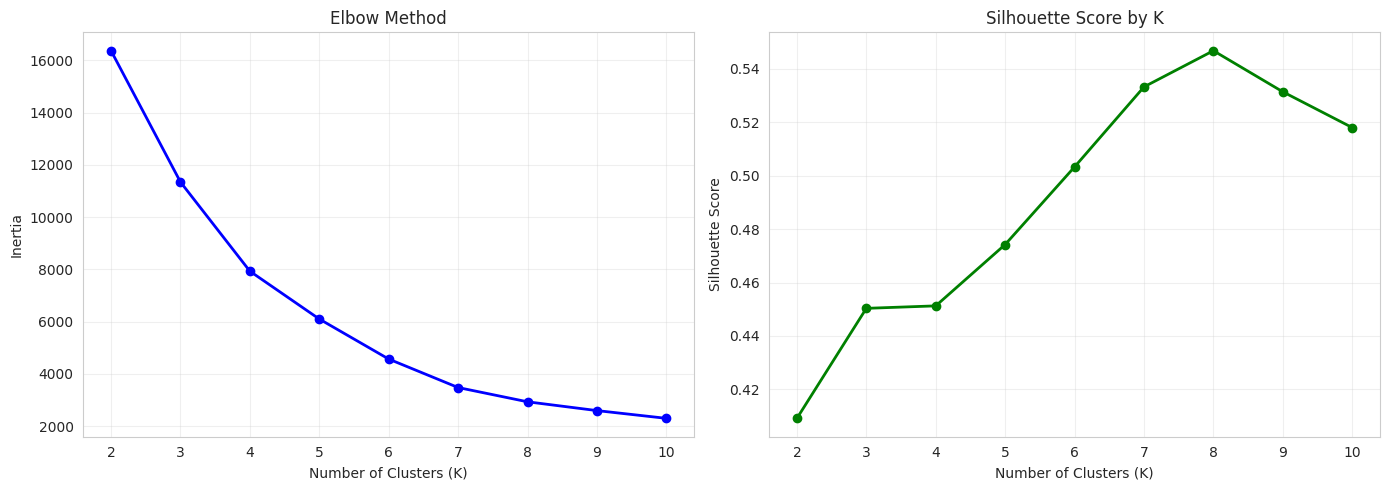


Silhouette Scores:
K=2: 0.409
K=3: 0.450
K=4: 0.451
K=5: 0.474
K=6: 0.503
K=7: 0.533
K=8: 0.547
K=9: 0.531
K=10: 0.518


In [90]:
from sklearn.cluster import KMeans

# Elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_cluster_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inertia
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/03_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSilhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: {score:.3f}")

In [91]:
# Train final model with K=5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
df_analysis['Segment'] = kmeans.fit_predict(X_cluster_scaled)

print(f"Segment Distribution:")
print(df_analysis['Segment'].value_counts().sort_index())

# Save model
joblib.dump(kmeans, 'models/kmeans_model.pkl')

Segment Distribution:
Segment
0     682
1    1858
2    1715
3    1929
4     859
Name: count, dtype: int64


['models/kmeans_model.pkl']


SEGMENT CHARACTERISTICS
         Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_RSS  Avg_Tenure  \
Segment                                                                  
0               9.04           1.98         80.48     0.39        2.96   
1               0.24           1.33         79.15     3.19       48.99   
2               0.36           0.31         29.24     0.19       36.16   
3               0.27           1.94         90.04     0.86       36.69   
4               9.47           0.59         35.31     0.41        2.53   

         Avg_Monthly  Churn_%  
Segment                        
0              80.48    72.73  
1              79.15    10.60  
2              29.24     8.34  
3              90.04    36.96  
4              35.31    37.25  

--- SEGMENT 0 ---
Size: 682 customers (9.7%)
Avg Recency: 9.0 (days since activity)
Avg Monetary: $80.48/month
Avg RSS Score: 0.4
Churn Rate: 72.7%
Avg Tenure: 3.0 months

--- SEGMENT 1 ---
Size: 1858 customers (26.4%)
Avg Recency:

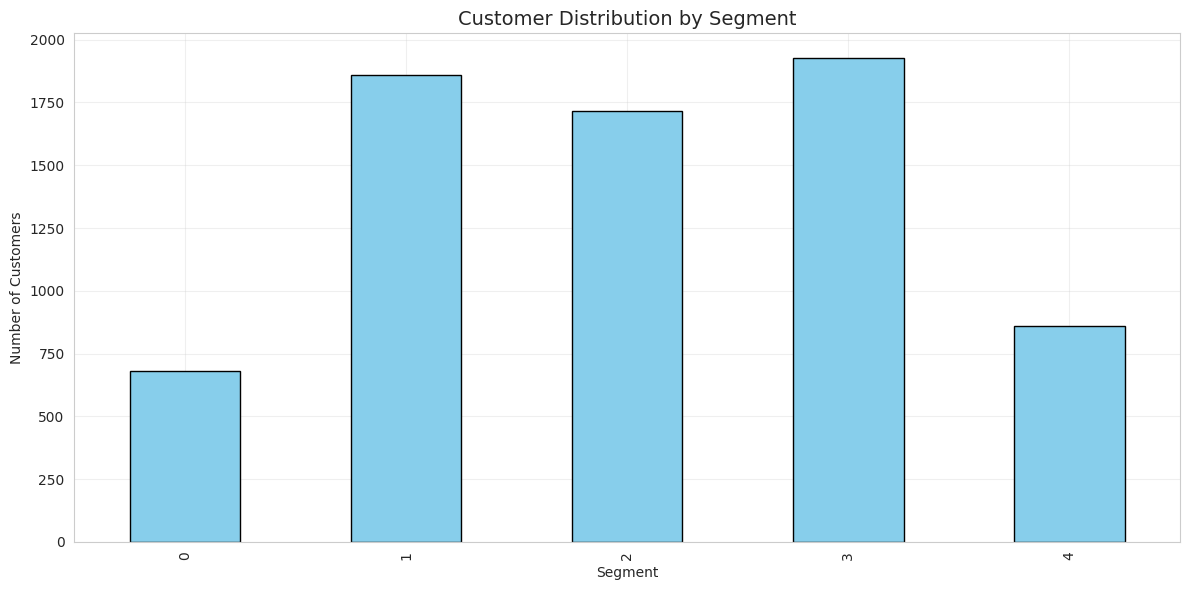

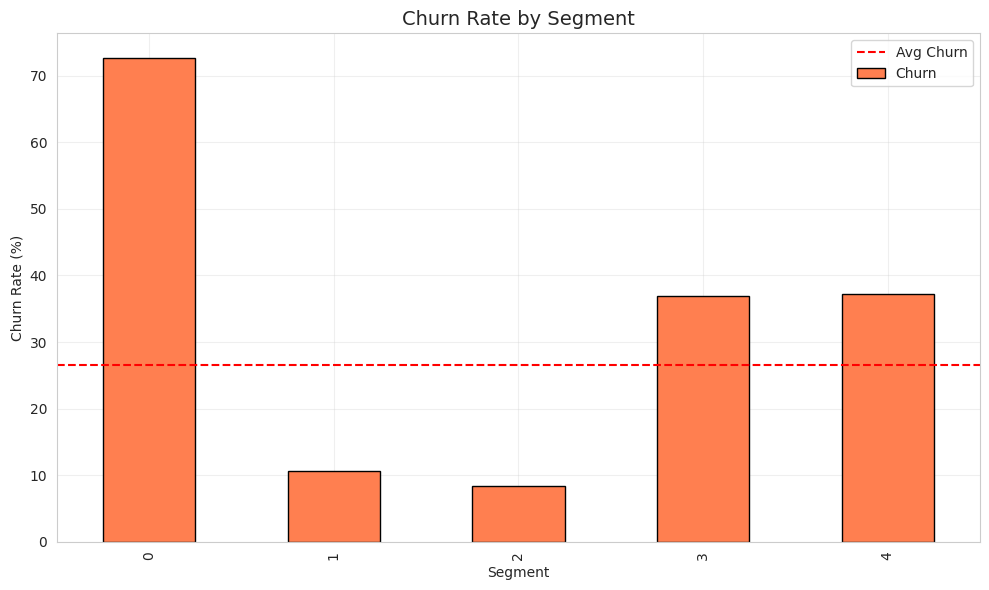

In [92]:
# Business interpretation of each segment
segment_analysis = df_analysis.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RSS_Score': 'mean',
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'Churn': lambda x: (x.sum() / len(x) * 100)  # Churn %
}).round(2)

segment_analysis.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary',
                             'Avg_RSS', 'Avg_Tenure', 'Avg_Monthly', 'Churn_%']

print("\n" + "="*80)
print("SEGMENT CHARACTERISTICS")
print("="*80)
print(segment_analysis)

# Name segments based on characteristics
segment_names = {
    0: 'Segment_0',
    1: 'Segment_1',
    2: 'Segment_2',
    3: 'Segment_3',
    4: 'Segment_4'
}

# Assign meaningful names (after analyzing)
for seg in range(optimal_k):
    seg_data = df_analysis[df_analysis['Segment'] == seg]
    print(f"\n--- SEGMENT {seg} ---")
    print(f"Size: {len(seg_data)} customers ({len(seg_data)/len(df_analysis)*100:.1f}%)")
    print(f"Avg Recency: {seg_data['Recency'].mean():.1f} (days since activity)")
    print(f"Avg Monetary: ${seg_data['Monetary'].mean():.2f}/month")
    print(f"Avg RSS Score: {seg_data['RSS_Score'].mean():.1f}")
    print(f"Churn Rate: {(seg_data['Churn'].sum()/len(seg_data)*100):.1f}%")
    print(f"Avg Tenure: {seg_data['tenure'].mean():.1f} months")

# Visualize segments
plt.figure(figsize=(12, 6))
pd.Series(df_analysis['Segment'].value_counts().sort_index()).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Customer Distribution by Segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/04_segment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Churn by segment
churn_by_segment = df_analysis.groupby('Segment')['Churn'].apply(lambda x: x.sum()/len(x)*100)
plt.figure(figsize=(10, 6))
churn_by_segment.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Churn Rate (%)')
plt.grid(True, alpha=0.3)
plt.axhline(y=df_analysis['Churn'].mean()*100, color='red', linestyle='--', label='Avg Churn')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/05_churn_by_segment.png', dpi=300, bbox_inches='tight')
plt.show()

LTV Statistics:
Mean LTV: $3258.25
Median LTV: $1785.30
Max LTV: $14364.00
Min LTV: $0.00

LTV by Segment:
                mean     median           sum
Segment                                      
0         189.000488   146.1075  1.288983e+05
1        6465.609857  6275.8440  1.201310e+07
2        1252.950930  1082.4000  2.148811e+06
3        4455.404411  3984.1200  8.594475e+06
4          72.864884    41.5800  6.259094e+04


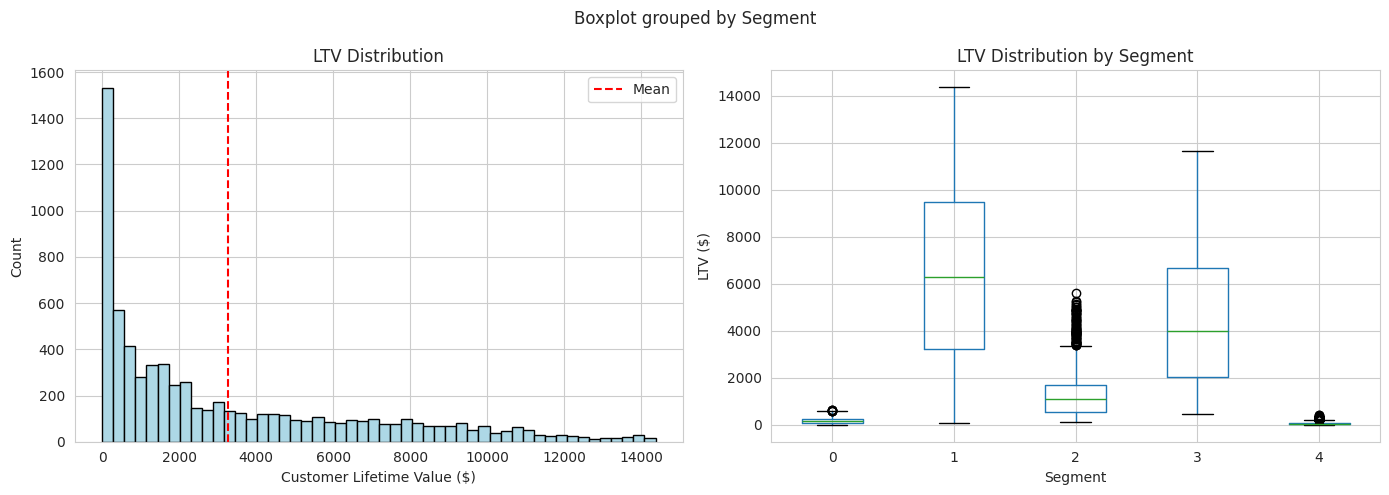


Value Tier Distribution:
Value_Tier
Medium    2395
High      2324
Low       2313
Name: count, dtype: int64


In [93]:
# Customer Lifetime Value Formula
# LTV = (Monthly Revenue) × (Months as Customer) × (Retention Multiplier)

# Basic approach
df_analysis['LTV_Basic'] = (
    df_analysis['MonthlyCharges'] *
    df_analysis['tenure'] *
    1.2  # 20% retention uplift assumption
)

# Segment-based approach (account for churn risk)
def calculate_ltv_advanced(row):
    base_ltv = row['MonthlyCharges'] * row['tenure']

    # Adjust by tenure (new customers = high churn risk)
    if row['tenure'] < 6:
        retention_factor = 0.7
    elif row['tenure'] < 12:
        retention_factor = 0.85
    else:
        retention_factor = 1.2

    # Adjust by RSS (engaged = higher LTV)
    rss_factor = 1 + (row['RSS_Score'] * 0.1)

    return base_ltv * retention_factor * rss_factor

df_analysis['LTV_Advanced'] = df_analysis.apply(calculate_ltv_advanced, axis=1)

print("LTV Statistics:")
print(f"Mean LTV: ${df_analysis['LTV_Advanced'].mean():.2f}")
print(f"Median LTV: ${df_analysis['LTV_Advanced'].median():.2f}")
print(f"Max LTV: ${df_analysis['LTV_Advanced'].max():.2f}")
print(f"Min LTV: ${df_analysis['LTV_Advanced'].min():.2f}")

# LTV by Segment
ltv_by_segment = df_analysis.groupby('Segment')['LTV_Advanced'].agg(['mean', 'median', 'sum'])
print("\nLTV by Segment:")
print(ltv_by_segment)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LTV distribution
axes[0].hist(df_analysis['LTV_Advanced'], bins=50, color='lightblue', edgecolor='black')
axes[0].set_xlabel('Customer Lifetime Value ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('LTV Distribution')
axes[0].axvline(df_analysis['LTV_Advanced'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

# LTV by segment (box plot)
df_analysis.boxplot(column='LTV_Advanced', by='Segment', ax=axes[1])
axes[1].set_title('LTV Distribution by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('LTV ($)')

plt.tight_layout()
plt.savefig('outputs/06_ltv_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Identify high-value customers
high_value_threshold = df_analysis['LTV_Advanced'].quantile(0.80)
df_analysis['Value_Tier'] = pd.cut(
    df_analysis['LTV_Advanced'],
    bins=[0, df_analysis['LTV_Advanced'].quantile(0.33),
          df_analysis['LTV_Advanced'].quantile(0.67), float('inf')],
    labels=['Low', 'Medium', 'High']
)

print("\nValue Tier Distribution:")
print(df_analysis['Value_Tier'].value_counts())

In [94]:
# =========================
# SEPARATE FEATURES & TARGET
# =========================

drop_cols_for_model = [
    'Churn',
    'LTV_Advanced',
    'LTV_Basic',
    'Value_Tier',
    'Recency',
    'Frequency',
    'Monetary',
    'RSS_Score'
]

# Optional: remove Segment if you don't want leakage from clustering
if 'Segment' in df_analysis.columns:
    drop_cols_for_model.append('Segment')

X = df_analysis.drop(columns=drop_cols_for_model, errors='ignore')
y = df_analysis['Churn']

# Safety checks
print("NaN in X:", X.isnull().sum().sum())
print("NaN in y:", y.isnull().sum())
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

NaN in X: 0
NaN in y: 0
X shape: (7043, 30)
y shape: (7043,)

Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)

print(f"\nTrain churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate: {y_test.mean()*100:.1f}%")

Train set: (5634, 30)
Test set: (1409, 30)

Train churn rate: 26.5%
Test churn rate: 26.5%


In [96]:
from sklearn.preprocessing import StandardScaler

scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

joblib.dump(scaler_model, 'models/scaler_model.pkl')

['models/scaler_model.pkl']

In [97]:
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score, precision_score, recall_score)

# XGBoost with class weight (handle imbalance)
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    scale_pos_weight=3,  # Penalize minority class (churn)
    eval_metric='logloss',
    verbosity=0
)

# Train
print("Training XGBoost model...")
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

print("✓ Model trained successfully!")

Training XGBoost model...
✓ Model trained successfully!


In [98]:
joblib.dump(xgb_model, 'models/xgb_churn_model.pkl')

['models/xgb_churn_model.pkl']

MODEL PERFORMANCE
Accuracy:  0.751
Precision: 0.520
Recall:    0.802
F1-Score:  0.631
ROC-AUC:   0.842

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409


Confusion Matrix:
[[758 277]
 [ 74 300]]


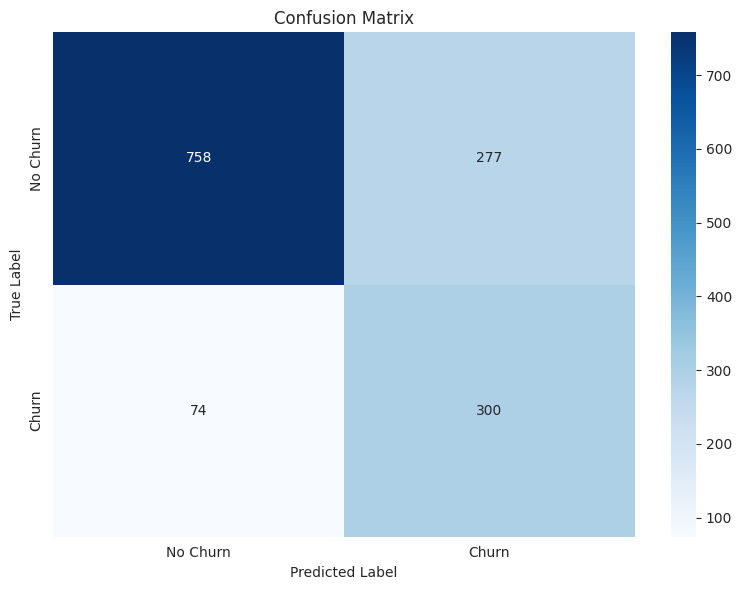

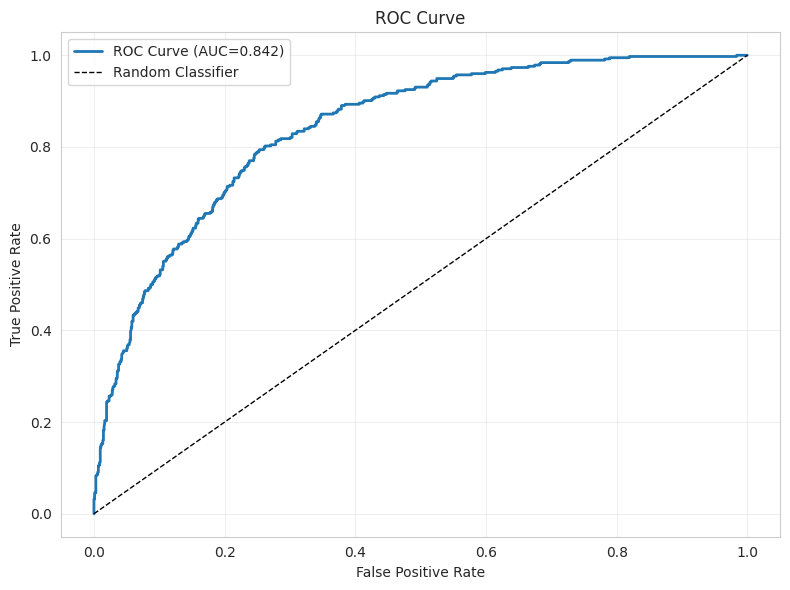

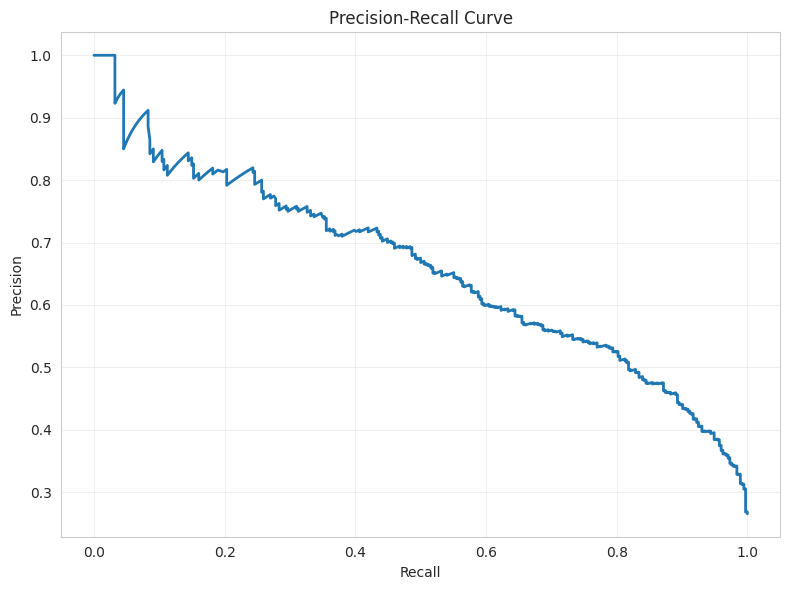

In [99]:
# Predictions
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

accuracy = (y_pred == y_test).mean()
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize Confusion Matrix
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('outputs/07_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/08_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/09_precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

Top 15 Most Important Features:
                           Feature  Importance
26               Contract_Two year    0.373019
25               Contract_One year    0.275888
11     InternetService_Fiber optic    0.103416
24             StreamingMovies_Yes    0.040050
12              InternetService_No    0.030759
28  PaymentMethod_Electronic check    0.018809
4                           tenure    0.018038
5                     PhoneService    0.012943
6                 PaperlessBilling    0.012201
8                     TotalCharges    0.011185
14              OnlineSecurity_Yes    0.010592
10               MultipleLines_Yes    0.010517
7                   MonthlyCharges    0.009682
20                 TechSupport_Yes    0.009418
22                 StreamingTV_Yes    0.009277


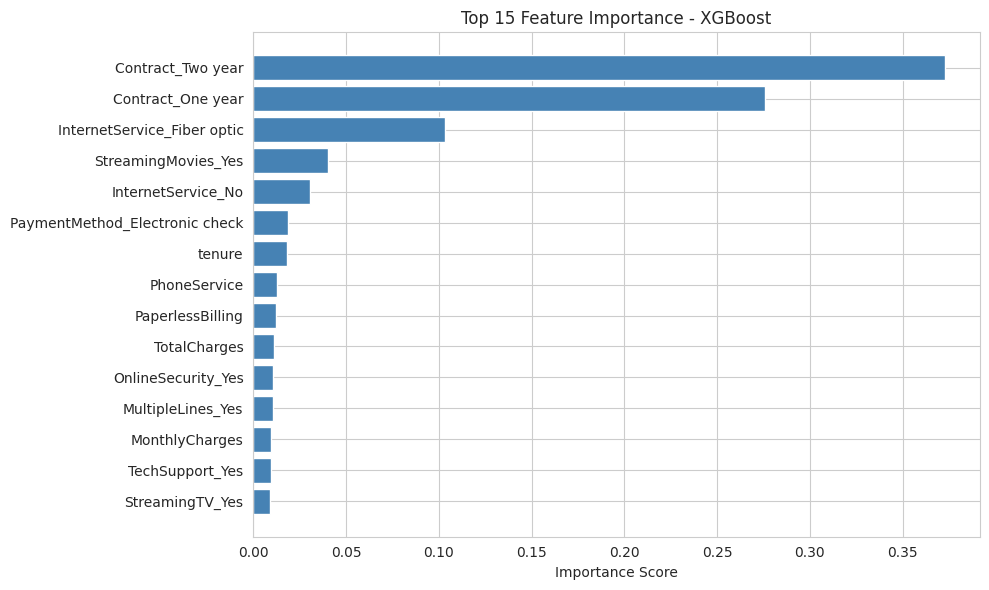

In [100]:
# XGBoost built-in feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(importance_df.head(15))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'].head(15), importance_df['Importance'].head(15), color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importance - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/10_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


Generating SHAP values (this may take 1-2 minutes)...
✓ SHAP values computed!


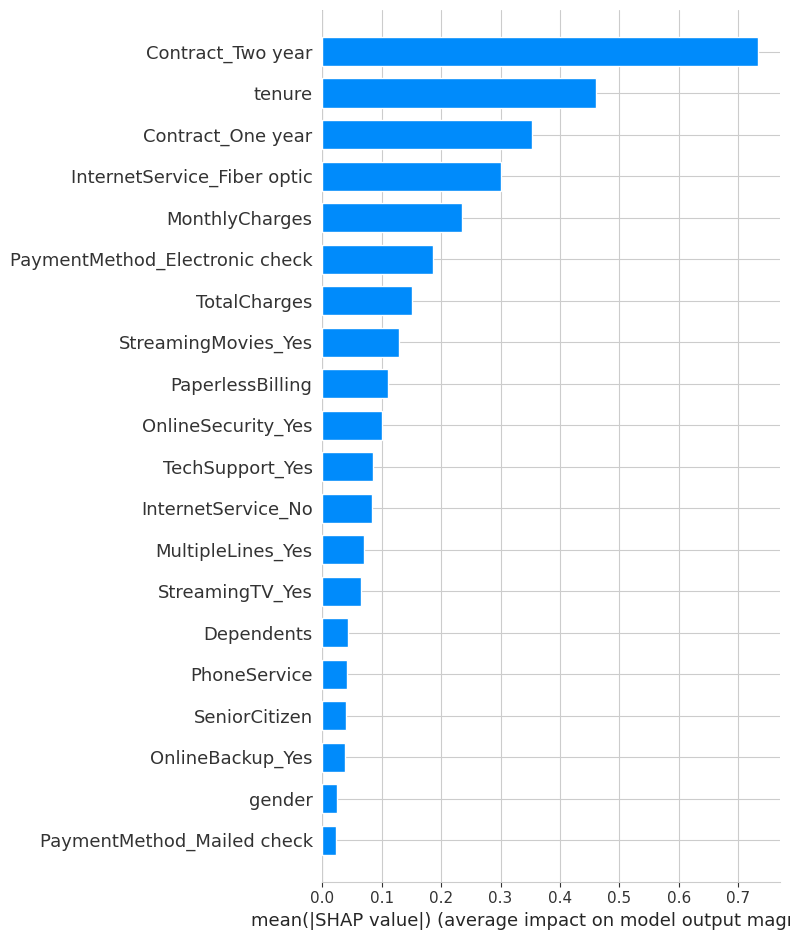

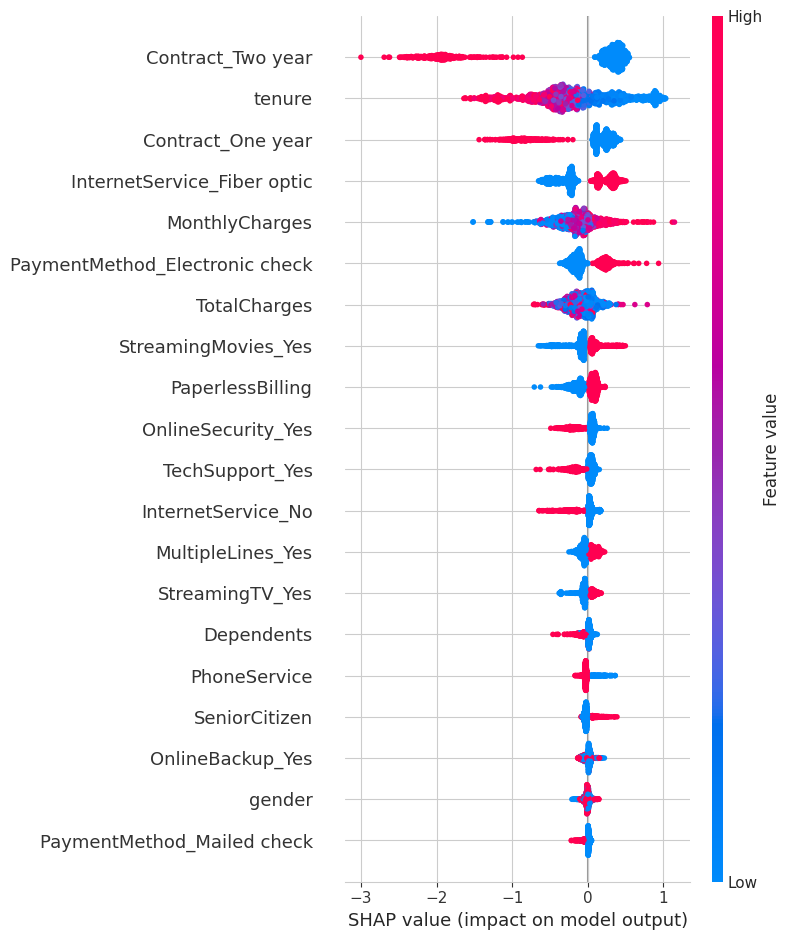


SHAP Summary:
- Red points: High feature values → High churn probability
- Blue points: Low feature values → Low churn probability
- Points on left: Feature decreases churn
- Points on right: Feature increases churn


In [101]:
import shap

print("\nGenerating SHAP values (this may take 1-2 minutes)...")

# Create explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

print("✓ SHAP values computed!")

# Summary plot (overall feature importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('outputs/11_shap_summary_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary plot (feature impact)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
plt.tight_layout()
plt.savefig('outputs/12_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSHAP Summary:")
print("- Red points: High feature values → High churn probability")
print("- Blue points: Low feature values → Low churn probability")
print("- Points on left: Feature decreases churn")
print("- Points on right: Feature increases churn")


High-Risk Customer Analysis
Customer Index: 1090
Churn Probability: 96.6%


<Figure size 1400x300 with 0 Axes>

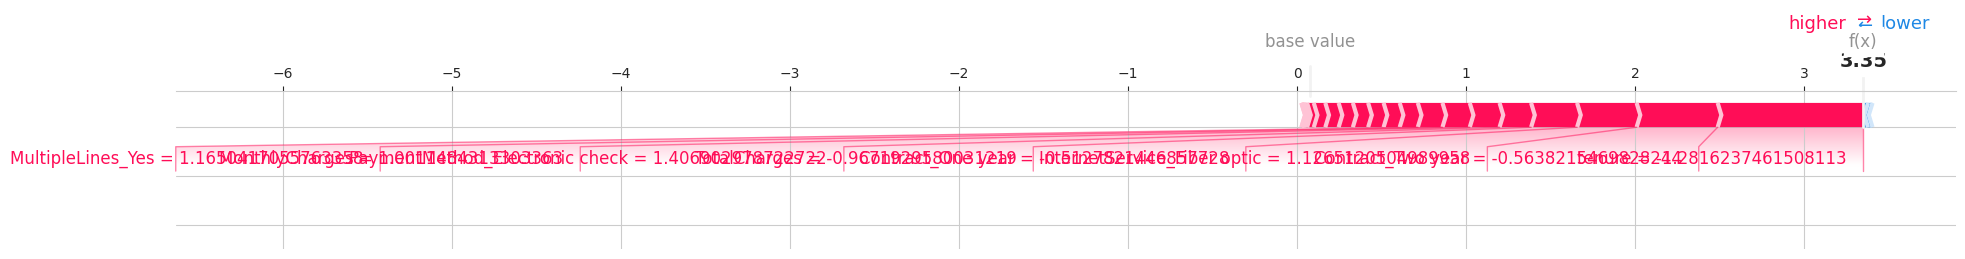


Top Features Contributing to Churn (for this customer):
                           Feature  SHAP_Value  Feature_Value
4                           tenure    0.861889      -1.281624
26               Contract_Two year    0.479611      -0.563822
11     InternetService_Fiber optic    0.352251       1.126512
25               Contract_One year    0.271996      -0.512782
8                     TotalCharges    0.186742      -0.967193
28  PaymentMethod_Electronic check    0.176296       1.406903
7                   MonthlyCharges    0.161498       1.001148
10               MultipleLines_Yes    0.145845       1.165042
22                 StreamingTV_Yes    0.107136       1.252163
6                 PaperlessBilling    0.095299       0.831495


In [103]:
# Pick a customer with high churn risk
high_risk_idx = y_pred_proba.argsort()[-1]  # Highest churn probability
high_risk_proba = y_pred_proba[high_risk_idx]

print(f"\nHigh-Risk Customer Analysis")
print(f"Customer Index: {high_risk_idx}")
print(f"Churn Probability: {high_risk_proba:.1%}")

# SHAP force plot
plt.figure(figsize=(14, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    X_test_scaled[high_risk_idx],
    feature_names=X.columns,
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig('outputs/13_shap_force_plot_high_risk.png', dpi=300, bbox_inches='tight')
plt.show()

# Show top contributing features
shap_impact = pd.DataFrame({
    'Feature': X.columns,
    'SHAP_Value': shap_values[high_risk_idx],
    'Feature_Value': X_test_scaled[high_risk_idx]
}).sort_values('SHAP_Value', ascending=False, key=abs)

print("\nTop Features Contributing to Churn (for this customer):")
print(shap_impact.head(10))




In [105]:
# =========================
# SEGMENT-LEVEL CHURN + LTV ANALYSIS
# =========================

# Customer-level predicted churn probability
df_analysis['Churn_Pred_Proba'] = xgb_model.predict_proba(X)[:, 1]

# Segment-level summary table
segment_churn_analysis = df_analysis.groupby('Segment').agg({
    'Churn_Pred_Proba': 'mean',
    'LTV_Advanced': 'mean',
    'RSS_Score': 'mean',
    'tenure': 'mean',
    'Monetary': 'mean'
}).round(3)

segment_churn_analysis.columns = [
    'Predicted_Churn_Risk',
    'Avg_LTV',
    'Avg_RSS',
    'Avg_Tenure',
    'Avg_Monetary'
]

print(segment_churn_analysis)

         Predicted_Churn_Risk   Avg_LTV  Avg_RSS  Avg_Tenure  Avg_Monetary
Segment                                                                   
0                       0.087   189.000    0.390       2.957        80.477
1                       0.072  6465.610    3.187      48.985        79.151
2                       0.068  1252.951    0.191      36.155        29.242
3                       0.069  4455.404    0.865      36.690        90.042
4                       0.099    72.865    0.411       2.534        35.305


In [106]:
# Create actionable recommendations
def get_retention_action(segment_row):
    """
    Business logic for retention actions
    """
    churn_risk = segment_row['Predicted_Churn_Risk']
    ltv = segment_row['Avg_LTV']
    rss = segment_row['Avg_RSS']
    tenure = segment_row['Avg_Tenure']

    # Segment value classification
    if ltv > df_analysis['LTV_Advanced'].quantile(0.75):
        value = 'HIGH_VALUE'
    elif ltv > df_analysis['LTV_Advanced'].quantile(0.25):
        value = 'MEDIUM_VALUE'
    else:
        value = 'LOW_VALUE'

    # Decision matrix
    recommendations = []
    budget = 0

    if churn_risk > 0.5 and value == 'HIGH_VALUE':
        recommendations.append("🔴 CRITICAL: Targeted retention campaign")
        recommendations.append("  • VIP dedicated support")
        recommendations.append("  • Personalized discount (15-20%)")
        recommendations.append("  • Priority customer service")
        budget = 1000

    elif churn_risk > 0.4 and value in ['HIGH_VALUE', 'MEDIUM_VALUE']:
        recommendations.append("🟡 WARNING: Increase engagement")
        recommendations.append("  • Personalized offers (10-15%)")
        recommendations.append("  • New feature early access")
        recommendations.append("  • Service upgrade suggestions")
        budget = 500

    elif churn_risk < 0.3 and value == 'HIGH_VALUE':
        recommendations.append("🟢 LOYALTY: Maximize value")
        recommendations.append("  • Exclusive benefits tier")
        recommendations.append("  • Referral incentives")
        recommendations.append("  • Premium features access")
        budget = 300

    elif churn_risk > 0.6 and value == 'LOW_VALUE':
        recommendations.append("⚫ LOW PRIORITY: Monitor only")
        recommendations.append("  • Generic retention emails")
        recommendations.append("  • No personalized spending")
        budget = 0

    else:
        recommendations.append("🔵 STANDARD: Regular engagement")
        recommendations.append("  • Monthly newsletter")
        recommendations.append("  • Seasonal promotions")
        budget = 100

    return '\\n'.join(recommendations), budget

# Create recommendations table
strategy_df = segment_churn_analysis.copy()
strategy_df['Action'] = ''
strategy_df['Est_Budget'] = 0

for idx in strategy_df.index:
    action, budget = get_retention_action(strategy_df.loc[idx])
    strategy_df.loc[idx, 'Action'] = action
    strategy_df.loc[idx, 'Est_Budget'] = budget

print("\n" + "="*100)
print("RETENTION STRATEGY BY SEGMENT")
print("="*100)

for seg in strategy_df.index:
    print(f"\n{'─'*100}")
    print(f"SEGMENT {seg}")
    print(f"{'─'*100}")
    print(f"Size: {df_analysis[df_analysis['Segment']==seg].shape[0]} customers")
    print(f"Churn Risk: {strategy_df.loc[seg, 'Predicted_Churn_Risk']:.1%}")
    print(f"Avg LTV: ${strategy_df.loc[seg, 'Avg_LTV']:.2f}")
    print(f"Avg Tenure: {strategy_df.loc[seg, 'Avg_Tenure']:.0f} months")
    print(f"\nRECOMMENDED ACTIONS:")
    print(strategy_df.loc[seg, 'Action'])
    print(f"Estimated Monthly Budget: ${strategy_df.loc[seg, 'Est_Budget']:,.0f}")

print(f"\n{'═'*100}")
print(f"TOTAL MONTHLY RETENTION BUDGET: ${strategy_df['Est_Budget'].sum():,.0f}")
print(f"TOTAL CUSTOMERS AT RISK: {len(df_analysis[df_analysis['Churn_Pred_Proba'] > 0.5])}")
print(f"POTENTIAL REVENUE AT RISK: ${df_analysis[df_analysis['Churn_Pred_Proba'] > 0.5]['Monetary'].sum():,.0f}")
print(f"{'═'*100}")


RETENTION STRATEGY BY SEGMENT

────────────────────────────────────────────────────────────────────────────────────────────────────
SEGMENT 0
────────────────────────────────────────────────────────────────────────────────────────────────────
Size: 682 customers
Churn Risk: 8.7%
Avg LTV: $189.00
Avg Tenure: 3 months

RECOMMENDED ACTIONS:
🔵 STANDARD: Regular engagement\n  • Monthly newsletter\n  • Seasonal promotions
Estimated Monthly Budget: $100

────────────────────────────────────────────────────────────────────────────────────────────────────
SEGMENT 1
────────────────────────────────────────────────────────────────────────────────────────────────────
Size: 1858 customers
Churn Risk: 7.2%
Avg LTV: $6465.61
Avg Tenure: 49 months

RECOMMENDED ACTIONS:
🟢 LOYALTY: Maximize value\n  • Exclusive benefits tier\n  • Referral incentives\n  • Premium features access
Estimated Monthly Budget: $300

──────────────────────────────────────────────────────────────────────────────────────────────

In [108]:
# =========================
# EXPORT TEST-SET PREDICTIONS FOR BUSINESS TEAM
# =========================

# Create test-set export using test indices from train_test_split
export_df = df_analysis.loc[X_test.index].copy()

export_df = export_df[['Segment', 'tenure', 'MonthlyCharges', 'Churn',
                       'Churn_Pred_Proba', 'LTV_Advanced', 'RSS_Score', 'Value_Tier']]

# Add risk level
export_df['Risk_Level'] = pd.cut(
    export_df['Churn_Pred_Proba'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical'],
    include_lowest=True
)

# Save
export_df.to_csv('outputs/customer_churn_predictions.csv', index=False)
print("\n✓ Predictions exported: outputs/customer_churn_predictions.csv")

# Summary statistics
print("\nTop 10 Highest Churn Risk Customers:")
print(
    export_df.nlargest(10, 'Churn_Pred_Proba')[
        ['Segment', 'MonthlyCharges', 'Churn_Pred_Proba', 'LTV_Advanced']
    ]
)

print("\nTop 10 Highest Value Customers:")
print(
    export_df.nlargest(10, 'LTV_Advanced')[
        ['Segment', 'Churn_Pred_Proba', 'LTV_Advanced', 'tenure']
    ]
)


✓ Predictions exported: outputs/customer_churn_predictions.csv

Top 10 Highest Churn Risk Customers:
      Segment  MonthlyCharges  Churn_Pred_Proba  LTV_Advanced
5218        4           19.70          0.230018        0.0000
6377        4           44.65          0.218848       40.6315
1144        4           35.55          0.218848       24.8850
6979        4           24.20          0.218617       16.9400
6509        4           25.05          0.218617       17.5350
376         4           25.35          0.218617       17.7450
3753        4           29.15          0.218617       24.4860
936         0           80.85          0.201761        0.0000
1334        4           25.20          0.182184       17.6400
185         4           24.80          0.182184       17.3600

Top 10 Highest Value Customers:
      Segment  Churn_Pred_Proba  LTV_Advanced  tenure
4206        1          0.074418     14128.128      72
3897        1          0.074418     13970.880      72
4737        1        

In [109]:
import joblib

joblib.dump(X.columns.tolist(), 'models/feature_columns.pkl')
print("Feature columns saved")

Feature columns saved
